In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU active: {gpus[0].name}")
else:
    print("❌ No GPU! Go to: Runtime → Change Runtime Type → T4 GPU")
    print("   Training will be 10x slower without GPU.")

!pip install -q kaggle scikit-learn seaborn matplotlib
print("Libraries ready!")

✅ GPU active: /physical_device:GPU:0
Libraries ready!


In [ ]:
# ── All checkpoints save here — survives disconnections ───────
from google.colab import drive
import os

drive.mount('/content/drive')

CHECKPOINT_DIR = '/content/drive/MyDrive/pneumonia_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_PATH = f'{CHECKPOINT_DIR}/latest_model.keras'
BEST_MODEL_PATH = f'{CHECKPOINT_DIR}/best_model.keras'
EPOCH_FILE      = f'{CHECKPOINT_DIR}/last_epoch.txt'

print(f"✅ Checkpoint folder ready:\n   {CHECKPOINT_DIR}")


Mounted at /content/drive
✅ Checkpoint folder ready:
   /content/drive/MyDrive/pneumonia_checkpoints


In [ ]:
# ── Upload your kaggle.json first ─────────────────────────────
# How to get it:
#   1. Go to kaggle.com → click your profile picture (top right)
#   2. Settings → scroll to "API" section → "Create New Token"
#   3. It downloads kaggle.json — upload that file below

from google.colab import files
print("Please upload your kaggle.json file:")
files.upload()

# Move it to the right place
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.system("cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
print("✅ Kaggle API configured!")

Please upload your kaggle.json file:


Saving Kaggle_api.txt to Kaggle_api.txt
✅ Kaggle API configured!


In [ ]:
# ── Download + unzip ──────────────────────────────────────────
# Dataset: "Chest X-Ray Images (Pneumonia)" — 5,863 JPEG images
# 2 classes: NORMAL and PNEUMONIA
# Already split into train / val / test folders

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip
print("✅ Dataset ready!")
print("\nFolder structure:")
!find chest_xray -type d

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:58<00:00, 42.5MB/s]

✅ Dataset ready!

Folder structure:
chest_xray
chest_xray/test
chest_xray/test/PNEUMONIA
chest_xray/test/NORMAL
chest_xray/train
chest_xray/train/PNEUMONIA
chest_xray/train/NORMAL
chest_xray/__MACOSX
chest_xray/__MACOSX/chest_xray
chest_xray/__MACOSX/chest_xray/test
chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
chest_xray/__MACOSX/chest_xray/test/NORMAL
chest_xray/__MACOSX/chest_xray/train
chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
chest_xray/__MACOSX/chest_xray/train/NORMAL
chest_xray/__MACOSX/chest_xray/val
chest_xray/__MACOSX/chest_xray/val/PNEUMONIA
chest_xray/__MACOSX/chest_xray/val/NORMAL
chest_xray/chest_xray
chest_xray/chest_xray/test
chest_xray/chest_xray/test/PNEUMONIA
chest_xray/chest_xray/test/NORMAL
chest_xray/chest_xray/train
chest_xray/chest_xray/train/PNEUMONIA
chest_xray/chest_xray/train/NORMAL
chest_xray/chest_xray/val
che

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  ALL HYPERPARAMETERS IN ONE PLACE
#  Change these values to experiment — that's the assignment's
#  "optimizing hyperparameters" requirement
# ═══════════════════════════════════════════════════════════════

IMG_SIZE      = 224     # VGG16 was designed for 224×224 px input
BATCH_SIZE    = 32      # how many images processed together per step
EPOCHS_P1     = 15      # max epochs for phase 1 (head training)
EPOCHS_P2     = 8       # max epochs for phase 2 (fine-tuning)
LR_PHASE1     = 0.0001  # learning rate for phase 1
LR_PHASE2     = 0.00001 # much smaller LR for fine-tuning (1e-5)
DROPOUT_RATE  = 0.5     # % of neurons randomly switched off during training
DENSE_UNITS   = 256     # neurons in our custom fully-connected layer
NUM_CLASSES   = 2       # NORMAL, PNEUMONIA

# Paths
TRAIN_DIR = 'chest_xray/train'
VAL_DIR   = 'chest_xray/val'
TEST_DIR  = 'chest_xray/test'

print("Hyperparameters set:")
print(f"  IMG_SIZE     = {IMG_SIZE}")
print(f"  BATCH_SIZE   = {BATCH_SIZE}")
print(f"  EPOCHS_P1    = {EPOCHS_P1}")
print(f"  EPOCHS_P2    = {EPOCHS_P2}")
print(f"  LR_PHASE1    = {LR_PHASE1}")
print(f"  LR_PHASE2    = {LR_PHASE2}")
print(f"  DROPOUT_RATE = {DROPOUT_RATE}")
print(f"  DENSE_UNITS  = {DENSE_UNITS}")



Hyperparameters set:
  IMG_SIZE     = 224
  BATCH_SIZE   = 32
  EPOCHS_P1    = 15
  EPOCHS_P2    = 8
  LR_PHASE1    = 0.0001
  LR_PHASE2    = 1e-05
  DROPOUT_RATE = 0.5
  DENSE_UNITS  = 256


In [ ]:
#TASK 1 — Dataset Understanding & Visualization
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import numpy as np

# ── Count images per split + class ────────────────────────────
print("Dataset Summary:")
print("─" * 45)
total_train_n = len(os.listdir(f'{TRAIN_DIR}/NORMAL'))
total_train_p = len(os.listdir(f'{TRAIN_DIR}/PNEUMONIA'))
total_val_n   = len(os.listdir(f'{VAL_DIR}/NORMAL'))
total_val_p   = len(os.listdir(f'{VAL_DIR}/PNEUMONIA'))
total_test_n  = len(os.listdir(f'{TEST_DIR}/NORMAL'))
total_test_p  = len(os.listdir(f'{TEST_DIR}/PNEUMONIA'))

for split, n, p in [
    ('Train', total_train_n, total_train_p),
    ('Val',   total_val_n,   total_val_p),
    ('Test',  total_test_n,  total_test_p),
]:
    print(f"  {split:6s} | NORMAL: {n:4d}  | PNEUMONIA: {p:4d}  | Total: {n+p}")
print("─" * 45)
print(f"\n⚠️  Class imbalance ratio: {total_train_p/total_train_n:.1f}x more PNEUMONIA than NORMAL")
print("   We will handle this with class_weight in training.")



Dataset Summary:
─────────────────────────────────────────────
  Train  | NORMAL: 1341  | PNEUMONIA: 3875  | Total: 5216
  Val    | NORMAL:    8  | PNEUMONIA:    8  | Total: 16
  Test   | NORMAL:  234  | PNEUMONIA:  390  | Total: 624
─────────────────────────────────────────────

⚠️  Class imbalance ratio: 2.9x more PNEUMONIA than NORMAL
   We will handle this with class_weight in training.


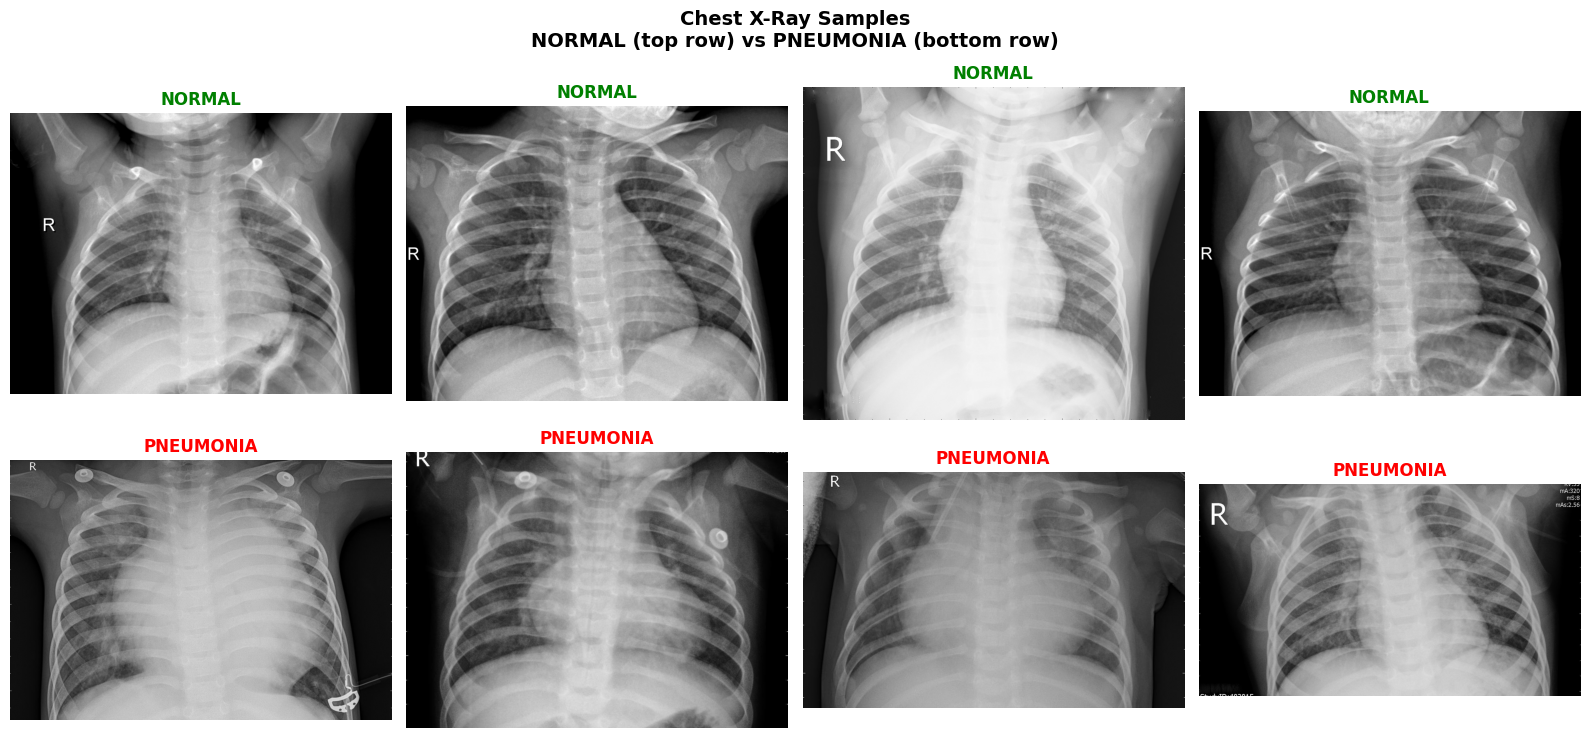

✅ Sample image plot saved to Drive


In [ ]:
# ── Show sample images ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Chest X-Ray Samples\nNORMAL (top row) vs PNEUMONIA (bottom row)',
             fontsize=14, fontweight='bold')

for col in range(4):
    # NORMAL row
    path_n  = f'{TRAIN_DIR}/NORMAL'
    img_n   = mpimg.imread(os.path.join(path_n, random.choice(os.listdir(path_n))))
    axes[0][col].imshow(img_n, cmap='gray')
    axes[0][col].set_title('NORMAL', color='green', fontweight='bold')
    axes[0][col].axis('off')

    # PNEUMONIA row
    path_p  = f'{TRAIN_DIR}/PNEUMONIA'
    img_p   = mpimg.imread(os.path.join(path_p, random.choice(os.listdir(path_p))))
    axes[1][col].imshow(img_p, cmap='gray')
    axes[1][col].set_title('PNEUMONIA', color='red', fontweight='bold')
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sample image plot saved to Drive")

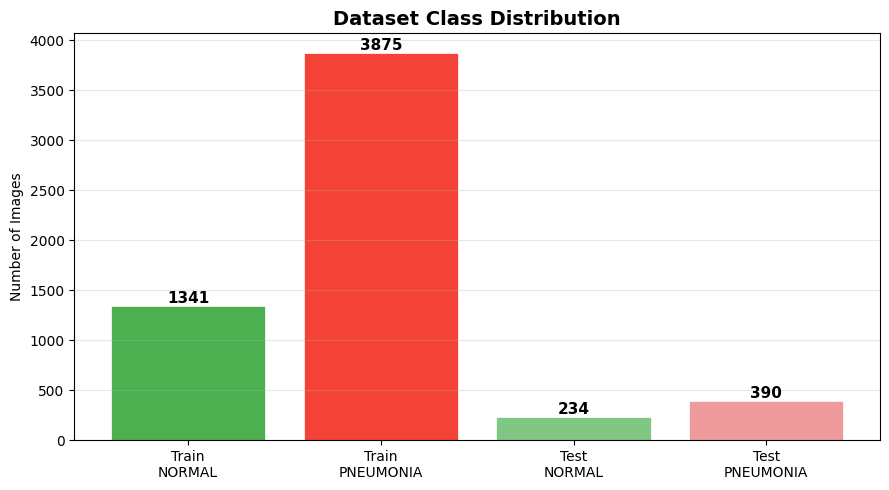

✅ Distribution chart saved to Drive


In [ ]:
	# ── Class distribution bar chart ─────────────────────────────
categories = ['Train\nNORMAL', 'Train\nPNEUMONIA', 'Test\nNORMAL', 'Test\nPNEUMONIA']
counts      = [total_train_n, total_train_p, total_test_n, total_test_p]
colors      = ['#4CAF50', '#F44336', '#81C784', '#EF9A9A']

plt.figure(figsize=(9, 5))
bars = plt.bar(categories, counts, color=colors, edgecolor='white', linewidth=0.5)
plt.title('Dataset Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images')
plt.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Distribution chart saved to Drive")

In [ ]:
#═══════════════════════════════════════════════════════════════
#  TASK 2 — Model Building: Data Preprocessing & Augmentation
# ═══════════════════════════════════════════════════════════════

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Training generator: augmented ─────────────────────────────
# Augmentation = artificially create variation in training images
# So the model doesn't just memorize exact pixel positions
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize: pixel 0-255 → 0.0-1.0
    rotation_range=15,       # randomly rotate up to 15° (X-rays don't tilt much)
    width_shift_range=0.1,   # randomly shift left/right by 10%
    height_shift_range=0.1,  # randomly shift up/down by 10%
    zoom_range=0.1,          # random zoom in/out by 10%
    horizontal_flip=True,    # flip left-right (lungs are symmetric)
    fill_mode='nearest'      # fill any new empty pixels with nearest pixel value
)

# ── Val & Test generators: NO augmentation ────────────────────
# We only normalize — we want real, unmodified images for evaluation
eval_datagen = ImageDataGenerator(rescale=1./255)

# ── Connect generators to folders ─────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # one-hot: [1,0]=NORMAL, [0,1]=PNEUMONIA
    color_mode='rgb',          # VGG16 needs 3 channels; grayscale X-rays get duplicated
    shuffle=True
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False              # MUST be False — order matters for evaluation
)

print(f"\nClass mapping: {train_gen.class_indices}")
print(f"  → NORMAL = index 0,  PNEUMONIA = index 1")
print(f"\nTraining batches   : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test batches       : {len(test_gen)}")



Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
  → NORMAL = index 0,  PNEUMONIA = index 1

Training batches   : 163
Validation batches : 1
Test batches       : 20


In [ ]:
## ── Class weights: penalize mistakes on minority class ─────────
# PNEUMONIA: 3875 images   NORMAL: 1341 images
# Without this, the model learns to just say "PNEUMONIA" for everything
# and gets 74% accuracy while being clinically useless

total_train = total_train_n + total_train_p

class_weights = {
    0: total_train / (NUM_CLASSES * total_train_n),  # NORMAL  → weight ~2.9
    1: total_train / (NUM_CLASSES * total_train_p),  # PNEUMONIA → weight ~1.0
}

print("Class weights applied during training:")
print(f"  NORMAL    (class 0): {class_weights[0]:.3f}")
print(f"  PNEUMONIA (class 1): {class_weights[1]:.3f}")
print(f"\n  → Getting a NORMAL case wrong costs the model "
      f"{class_weights[0]/class_weights[1]:.1f}x more")

Class weights applied during training:
  NORMAL    (class 0): 1.945
  PNEUMONIA (class 1): 0.673

  → Getting a NORMAL case wrong costs the model 2.9x more


In [ ]:
#CELL 8 — Build the Model
#python# ── Load VGG16 pre-trained base ────────────────────────────────
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = VGG16(
    weights='imagenet',            # weights from 1.2M ImageNet images
    include_top=False,             # remove VGG16's original 1000-class head
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze ALL base layers — don't touch what ImageNet already taught it
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 loaded: {len(base_model.layers)} layers, all frozen")
# ── Add our custom classification head ────────────────────────
x = base_model.output

# GlobalAveragePooling: shrinks (7, 7, 512) feature maps → (512,) vector
# Better than Flatten for small medical datasets — far fewer parameters
x = GlobalAveragePooling2D()(x)

# Dense: learns WHICH combinations of VGG16 features = pneumonia
x = Dense(DENSE_UNITS, activation='relu')(x)

# Dropout: randomly turns off 50% of neurons each training step
# Forces the model to not rely on any single path → reduces overfitting
x = Dropout(DROPOUT_RATE)(x)

# Output layer: 2 neurons with softmax
# Output looks like: [0.12, 0.88] → 88% confident it's PNEUMONIA
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Count parameters
trainable     = sum(p.numpy().size for p in model.trainable_weights)
non_trainable = sum(p.numpy().size for p in model.non_trainable_weights)
print(f"\nModel built successfully!")
print(f"  Trainable params     : {trainable:,}   ← our custom head only")
print(f"  Non-trainable params : {non_trainable:,}  ← VGG16 base (frozen)")
print(f"  Total params         : {trainable + non_trainable:,}")
#python# ── Save the freshly built model to Drive before training ──────
# This is your safety net — even if epoch 1 crashes, you have the start
model.save(f'{CHECKPOINT_DIR}/model_start.keras')
print("✅ Starting model saved to Drive!")




VGG16 loaded: 19 layers, all frozen

Model built successfully!
  Trainable params     : 131,842   ← our custom head only
  Non-trainable params : 14,714,688  ← VGG16 base (frozen)
  Total params         : 14,846,530
✅ Starting model saved to Drive!


In [ ]:
#CELL 9 — Define Callbacks (the checkpoint system)python
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, LambdaCallback)

# ── 1. Save model every epoch to Drive ────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor='val_loss',
    save_best_only=False,    # save EVERY epoch so we can always resume latest
    save_weights_only=False,
    verbose=1
)

# ── 2. Also separately save the best model ────────────────────
best_cb = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_loss',
    save_best_only=True,     # only updates when val_loss improves
    verbose=1
)

# ── 3. Stop early if model stops improving ────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # wait 5 epochs before giving up
    restore_best_weights=True,
    verbose=1
)

# ── 4. Reduce learning rate when stuck ────────────────────────
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,              # new_lr = old_lr × 0.3
    patience=2,              # reduce after 2 epochs of no improvement
    min_lr=1e-7,
    verbose=1
)

# ── 5. Save the epoch number after each epoch ─────────────────
def save_epoch_number(epoch, logs=None):
    with open(EPOCH_FILE, 'w') as f:
        f.write(str(epoch))

epoch_saver = LambdaCallback(on_epoch_end=save_epoch_number)

def get_initial_epoch():
    """Returns the last completed epoch, or 0 if starting fresh"""
    if os.path.exists(EPOCH_FILE):
        with open(EPOCH_FILE, 'r') as f:
            last = int(f.read().strip())
        print(f"📂 Epoch tracker found — last completed epoch: {last}")
        return last + 1   # resume from NEXT epoch
    return 0

print("✅ All callbacks defined!")
print(f"\nCheckpoints will be saved to:\n  {CHECKPOINT_DIR}")



✅ All callbacks defined!

Checkpoints will be saved to:
  /content/drive/MyDrive/pneumonia_checkpoints


In [ ]:
#🔵 CELL 10 — PHASE 1 Training (with auto-resume)
# ═══════════════════════════════════════════════════════════════
#  PHASE 1: Train the custom head
#  VGG16 base is frozen — only our Dense/Dropout/Softmax layers train
# ═══════════════════════════════════════════════════════════════

# ── Auto-resume: load checkpoint if one exists ────────────────
if os.path.exists(CHECKPOINT_PATH):
    print("✅ Checkpoint found! Loading from Drive...")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)
    initial_epoch = get_initial_epoch()
    print(f"   Resuming from epoch {initial_epoch}")
else:
    print("No checkpoint found — starting Phase 1 from scratch.")
    initial_epoch = 0

# ── Compile for Phase 1 ───────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=LR_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n{'='*52}")
print(f"  PHASE 1: Training epochs {initial_epoch+1} → {EPOCHS_P1}")
print(f"  Learning rate : {LR_PHASE1}")
print(f"  Base model    : FROZEN")
print(f"{'='*52}\n")

history_p1 = model.fit(
    train_gen,
    epochs=EPOCHS_P1,
    initial_epoch=initial_epoch,   # ← resumes from here, not from 0
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[
        checkpoint_cb,   # saves latest model to Drive after every epoch
        best_cb,         # saves best model to Drive when val_loss improves
        early_stop,      # stops if no improvement for 5 epochs
        reduce_lr,       # reduces LR when stuck
        epoch_saver      # writes epoch number to Drive
    ]
)

print("\n✅ Phase 1 complete!")



No checkpoint found — starting Phase 1 from scratch.

  PHASE 1: Training epochs 1 → 15
  Learning rate : 0.0001
  Base model    : FROZEN

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.5868 - loss: 0.6766
Epoch 1: saving model to /content/drive/MyDrive/pneumonia_checkpoints/latest_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_checkpoints/latest_model.keras

Epoch 1: val_loss improved from None to 0.55391, saving model to /content/drive/MyDrive/pneumonia_checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_checkpoints/best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 791ms/step - accuracy: 0.6505 - loss: 0.6236 - val_accuracy: 0.7500 - val_loss: 0.5539 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.7992 - loss: 0.4906
Epoch 2: saving model to /content/drive/MyDrive/pneumonia_checkpoints/latest_model.keras

Epoch 2: finished saving model to

In [ ]:
#🔵 CELL 11 — PHASE 2 Fine-Tuning
#python# ═══════════════════════════════════════════════════════════════
#  PHASE 2: Fine-tuning
#  Unfreeze the last 4 VGG16 layers so they can adapt to X-ray textures
#  Use a MUCH smaller learning rate to avoid destroying ImageNet weights
# ═══════════════════════════════════════════════════════════════

print("Unfreezing last 4 layers of VGG16 base...")
for layer in model.layers[-4:]:
    layer.trainable = True

# Check what got unfrozen
print("\nLayer trainability (last 8 layers):")
for layer in model.layers[-8:]:
    print(f"  {layer.name:30s}  trainable={layer.trainable}")

# Reset epoch tracker for Phase 2
if os.path.exists(EPOCH_FILE):
    os.remove(EPOCH_FILE)

# New callbacks for Phase 2
CHECKPOINT_P2 = f'{CHECKPOINT_DIR}/latest_model_p2.keras'
BEST_P2       = f'{CHECKPOINT_DIR}/best_model_p2.keras'

checkpoint_p2 = ModelCheckpoint(filepath=CHECKPOINT_P2, save_best_only=False, verbose=1)
best_p2       = ModelCheckpoint(filepath=BEST_P2, monitor='val_loss',
                                 save_best_only=True, verbose=1)
early_stop_p2 = EarlyStopping(monitor='val_loss', patience=4,
                               restore_best_weights=True, verbose=1)

# Recompile with tiny LR
model.compile(
    optimizer=Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n{'='*52}")
print(f"  PHASE 2: Fine-tuning — {EPOCHS_P2} epochs")
print(f"  Learning rate : {LR_PHASE2}  (10x smaller than Phase 1)")
print(f"  Last 4 layers : UNFROZEN")
print(f"{'='*52}\n")

history_p2 = model.fit(
    train_gen,
    epochs=EPOCHS_P2,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[checkpoint_p2, best_p2, early_stop_p2, reduce_lr, epoch_saver]
)

# Save final model
model.save(f'{CHECKPOINT_DIR}/final_model.keras')
print("\n✅ Phase 2 complete! Final model saved to Drive.")



Unfreezing last 4 layers of VGG16 base...

Layer trainability (last 8 layers):
  block5_conv1                    trainable=False
  block5_conv2                    trainable=False
  block5_conv3                    trainable=False
  block5_pool                     trainable=False
  global_average_pooling2d        trainable=True
  dense                           trainable=True
  dropout                         trainable=True
  dense_1                         trainable=True

  PHASE 2: Fine-tuning — 8 epochs
  Learning rate : 1e-05  (10x smaller than Phase 1)
  Last 4 layers : UNFROZEN

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.8939 - loss: 0.2675
Epoch 1: saving model to /content/drive/MyDrive/pneumonia_checkpoints/latest_model_p2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_checkpoints/latest_model_p2.keras

Epoch 1: val_loss improved from None to 0.42186, saving model to /content/drive/MyDrive/pneumonia_checkpoints/best_model_p2.kera

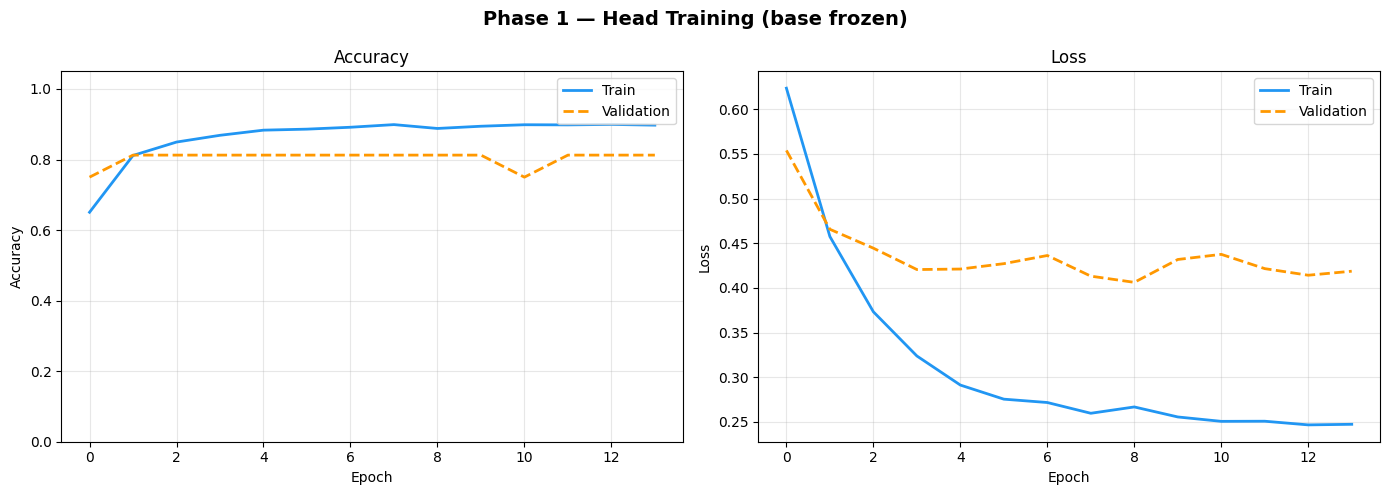

✅ Plot saved to Drive


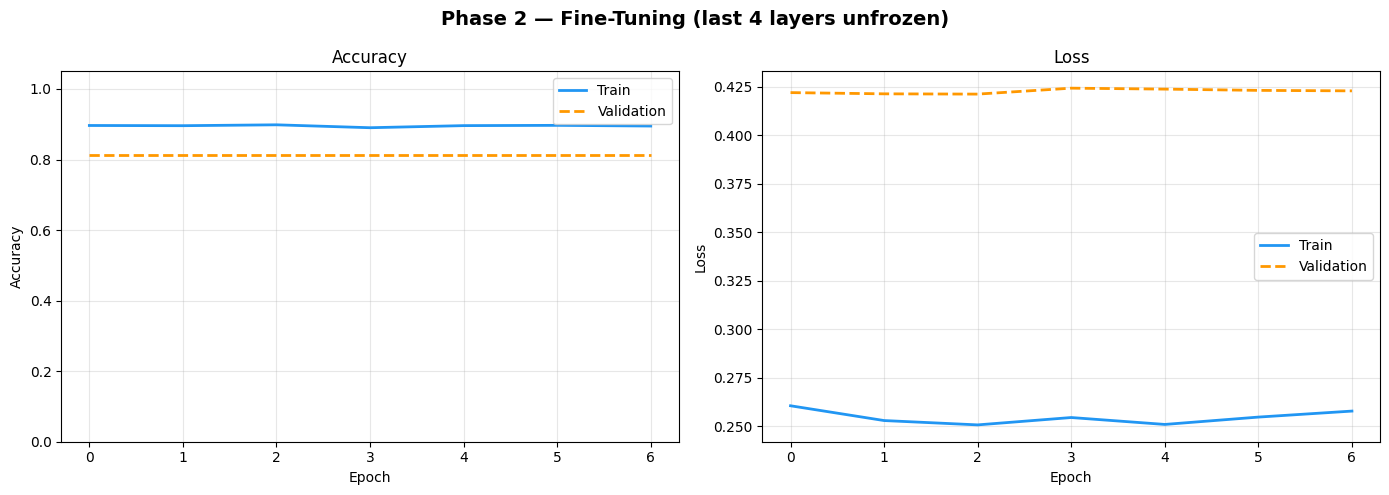

✅ Plot saved to Drive


In [ ]:
#🔵 CELL 12 — TASK 3: Plot Training Curves
# ═══════════════════════════════════════════════════════════════
#  TASK 3 — Evaluation & Performance Comparison
# ═══════════════════════════════════════════════════════════════

def plot_training_history(history, title):
    """Plots accuracy and loss curves for one training phase"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train',
             color='#2196F3', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation',
             color='#FF9800', linewidth=2, linestyle='--')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)

    # Loss
    ax2.plot(history.history['loss'],     label='Train',
             color='#2196F3', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation',
             color='#FF9800', linewidth=2, linestyle='--')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{CHECKPOINT_DIR}/curves_{safe_title}.png',
                dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot saved to Drive")

plot_training_history(history_p1, "Phase 1 — Head Training (base frozen)")
plot_training_history(history_p2, "Phase 2 — Fine-Tuning (last 4 layers unfrozen)")


In [ ]:
#🔵 CELL 13 — Get Predictions & All Metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score,
                              roc_curve, auc)
import seaborn as sns

# ── Load best model for evaluation ────────────────────────────
print("Loading best model for evaluation...")
best_model = tf.keras.models.load_model(BEST_P2)

# ── Run predictions on test set ───────────────────────────────
test_gen.reset()   # rewind generator to beginning — IMPORTANT
print("Running predictions on test set...")
y_pred_probs = best_model.predict(test_gen, verbose=1)

y_pred  = np.argmax(y_pred_probs, axis=1)   # [0,1,1,0,...] predicted classes
y_true  = test_gen.classes                   # [0,1,0,1,...] true classes
labels  = ['NORMAL', 'PNEUMONIA']

# ── Calculate all metrics ─────────────────────────────────────
acc       = np.mean(y_pred == y_true) * 100
precision = precision_score(y_true, y_pred, average='weighted') * 100
recall    = recall_score(y_true, y_pred, average='weighted') * 100
f1        = f1_score(y_true, y_pred, average='weighted') * 100

print(f"\n{'='*52}")
print(f"      FINAL MODEL PERFORMANCE SUMMARY")
print(f"{'='*52}")
print(f"  Accuracy  :  {acc:.2f}%")
print(f"  Precision :  {precision:.2f}%")
print(f"  Recall    :  {recall:.2f}%")
print(f"  F1-Score  :  {f1:.2f}%")
print(f"{'='*52}")
print(f"\nDetailed per-class report:")
print(classification_report(y_true, y_pred, target_names=labels))


Loading best model for evaluation...
Running predictions on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step

      FINAL MODEL PERFORMANCE SUMMARY
  Accuracy  :  84.46%
  Precision :  85.13%
  Recall    :  84.46%
  F1-Score  :  84.61%

Detailed per-class report:
              precision    recall  f1-score   support

      NORMAL       0.76      0.85      0.80       234
   PNEUMONIA       0.91      0.84      0.87       390

    accuracy                           0.84       624
   macro avg       0.83      0.85      0.84       624
weighted avg       0.85      0.84      0.85       624



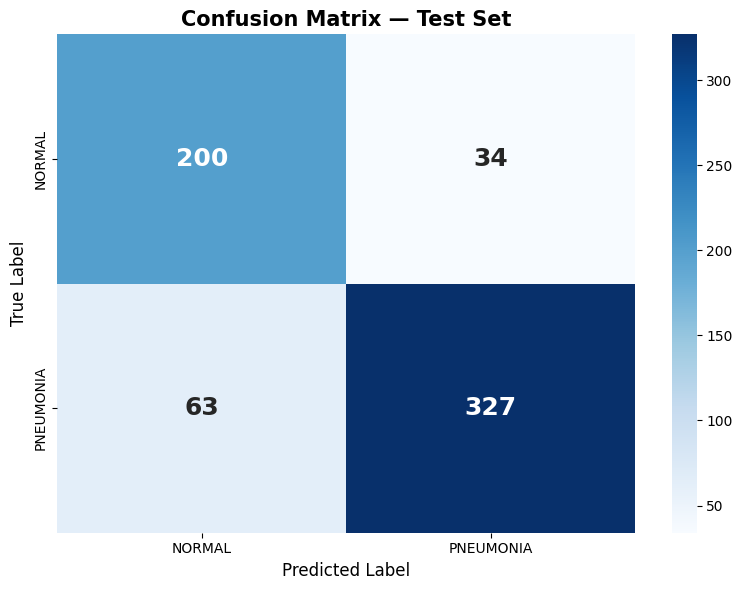


Breaking down the confusion matrix:
  ✅ True  Negative — correctly said NORMAL    : 200
  ⚠️  False Positive — said PNEUMONIA, was NORMAL: 34  (false alarm)
  ❌ False Negative — said NORMAL, was PNEUMONIA : 63  (dangerous miss!)
  ✅ True  Positive — correctly said PNEUMONIA  : 327

  In medicine, False Negatives (missed sick patients) are the worst outcome.
  Our model missed 63 pneumonia cases out of 390 total.


In [ ]:
#🔵 CELL 14 — Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 18, 'weight': 'bold'}, ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nBreaking down the confusion matrix:")
print(f"  ✅ True  Negative — correctly said NORMAL    : {tn}")
print(f"  ⚠️  False Positive — said PNEUMONIA, was NORMAL: {fp}  (false alarm)")
print(f"  ❌ False Negative — said NORMAL, was PNEUMONIA : {fn}  (dangerous miss!)")
print(f"  ✅ True  Positive — correctly said PNEUMONIA  : {tp}")
print(f"\n  In medicine, False Negatives (missed sick patients) are the worst outcome.")
print(f"  Our model missed {fn} pneumonia cases out of {tp+fn} total.")


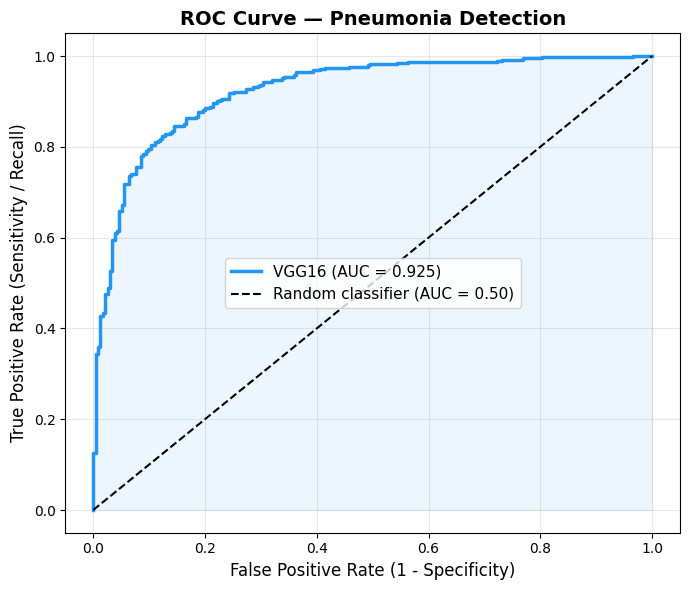


AUC = 0.925
  1.0 = perfect  |  0.5 = random guess
  Our model ranks a random sick patient above a random healthy one 92.5% of the time


In [ ]:
#🔵 CELL 15 — ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2196F3', lw=2.5,
         label=f'VGG16 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5,
         label='Random classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2196F3')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Pneumonia Detection', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"\nAUC = {roc_auc:.3f}")
print("  1.0 = perfect  |  0.5 = random guess")
print(f"  Our model ranks a random sick patient above a random healthy one "
      f"{roc_auc*100:.1f}% of the time")


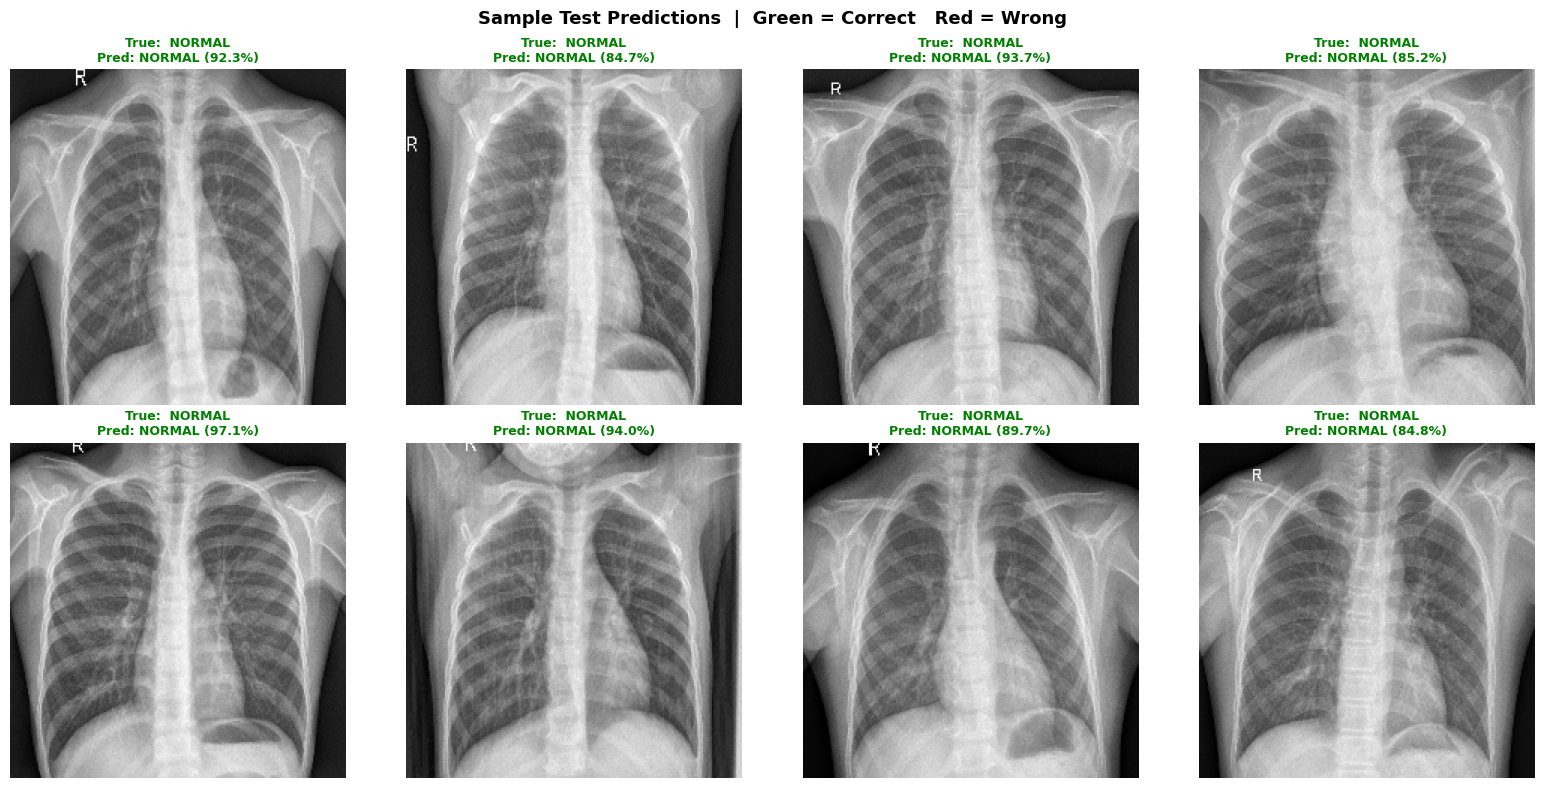

✅ Prediction samples saved to Drive


In [ ]:
#🔵 CELL 16 — Sample Predictions Visualization
test_gen.reset()
imgs, true_labels = next(test_gen)
preds = best_model.predict(imgs, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Test Predictions  |  Green = Correct   Red = Wrong',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(imgs[i][:, :, 0], cmap='gray')
    true_cls  = labels[np.argmax(true_labels[i])]
    pred_cls  = labels[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100
    correct    = true_cls == pred_cls
    axes[i].set_title(
        f"True:  {true_cls}\nPred: {pred_cls} ({confidence:.1f}%)",
        color='green' if correct else 'red',
        fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Prediction samples saved to Drive")

In [ ]:
#🔵 CELL 17 — Comparison with Published Research (your report section)
# ── Comparison table ──────────────────────────────────────────
import pandas as pd

comparison_data = {
    'Model / Study': [
        'Our Model (VGG16 + fine-tune)',
        'Sharma & Gulerial 2022 (VGG16+NN)',
        'Ayan & Unver 2019 (VGG16)',
        'Customized VGG16 (IEEE 2024)',
        'VGG16-based DL (Eur. J. 2025)',
    ],
    'Dataset': [
        'Kaggle Chest X-Ray (5,863)',
        'Kaggle Chest X-Ray (5,856)',
        'Kaggle Chest X-Ray (5,856)',
        'Kaggle Chest X-Ray',
        'Kaggle Chest X-Ray',
    ],
    'Accuracy (%)': [
        f'{acc:.2f}',
        '92.00', '87.00', '93.50', '92.79',
    ],
    'Precision (%)': [
        f'{precision:.2f}',
        '94.28', 'N/A', 'N/A', '94.12',
    ],
    'Recall (%)': [
        f'{recall:.2f}',
        '93.08', 'N/A', 'N/A', '94.36',
    ],
    'F1-Score (%)': [
        f'{f1:.2f}',
        '93.70', 'N/A', 'N/A', '94.24',
    ],
}

df = pd.DataFrame(comparison_data)
print("\nComparison with Published Results on Same Dataset:")
print(df.to_string(index=False))

# Save as CSV to Drive
df.to_csv(f'{CHECKPOINT_DIR}/comparison_table.csv', index=False)
print("\n✅ Comparison table saved to Drive as CSV")




Comparison with Published Results on Same Dataset:
                    Model / Study                    Dataset Accuracy (%) Precision (%) Recall (%) F1-Score (%)
    Our Model (VGG16 + fine-tune) Kaggle Chest X-Ray (5,863)        84.46         85.13      84.46        84.61
Sharma & Gulerial 2022 (VGG16+NN) Kaggle Chest X-Ray (5,856)        92.00         94.28      93.08        93.70
        Ayan & Unver 2019 (VGG16) Kaggle Chest X-Ray (5,856)        87.00           N/A        N/A          N/A
     Customized VGG16 (IEEE 2024)         Kaggle Chest X-Ray        93.50           N/A        N/A          N/A
    VGG16-based DL (Eur. J. 2025)         Kaggle Chest X-Ray        92.79         94.12      94.36        94.24

✅ Comparison table saved to Drive as CSV


In [ ]:
#🔵 CELL 18 — Final Summary & Drive File List
print("="*55)
print("           ASSIGNMENT COMPLETE ✅")
print("="*55)
print(f"\nAll files saved in Google Drive:")
print(f"  📁 {CHECKPOINT_DIR}/")

for fname in sorted(os.listdir(CHECKPOINT_DIR)):
    size = os.path.getsize(f'{CHECKPOINT_DIR}/{fname}')
    size_str = f"{size/1024/1024:.1f} MB" if size > 1024*1024 else f"{size/1024:.1f} KB"
    print(f"     📄 {fname:40s} {size_str}")

print(f"\nSubmission checklist:")
print(f"  ✅ Task 1 — Dataset explored, visualized, class imbalance noted")
print(f"  ✅ Task 2 — VGG16 transfer learning, 2-phase training, hyperparameters tuned")
print(f"  ✅ Task 3 — Accuracy {acc:.1f}%, Precision {precision:.1f}%,",
      f"Recall {recall:.1f}%, F1 {f1:.1f}%")
print(f"  ✅ Confusion matrix + ROC curve + sample predictions plotted")
print(f"  ✅ Comparison table with 4 published papers")
print(f"  ⬜ Push notebook to GitHub → paste link in Declaration cell")


           ASSIGNMENT COMPLETE ✅

All files saved in Google Drive:
  📁 /content/drive/MyDrive/pneumonia_checkpoints/
     📄 best_model.keras                         57.7 MB
     📄 best_model_p2.keras                      57.7 MB
     📄 class_distribution.png                   26.7 KB
     📄 comparison_table.csv                     0.4 KB
     📄 confusion_matrix.png                     27.1 KB
     📄 curves_Phase_1_—_Head_Training_base_frozen.png 53.7 KB
     📄 curves_Phase_2_—_Fine-Tuning_last_4_layers_unfrozen.png 43.7 KB
     📄 final_model.keras                        57.7 MB
     📄 last_epoch.txt                           0.0 KB
     📄 latest_model.keras                       57.7 MB
     📄 latest_model_p2.keras                    57.7 MB
     📄 model_start.keras                        56.7 MB
     📄 roc_curve.png                            49.2 KB
     📄 sample_images.png                        660.3 KB
     📄 sample_predictions.png                   784.2 KB

Submission checklist: